In [1]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import os
import skimage

# Leave Microscope Out

In [2]:
objects_color = {'Nuc':'#00A3FF',
                 'MN':'#A68CFF'}

datasets_colors = {'BBBC039':'#FFC0CB',
                   'MNFinder Data':'#80ED99',
                   'mnDINO_data_01':'#192A56',
                   'mnDINO_data_02':'#00A3FF'}

methods_color = {'mnDINO': '#00B4D8',
                 'mnDINO Hold Out': '#808080'}

sb.set(font_scale=1.3, style='white')

In [3]:
LOAD_PATH = '/hdd/jcaicedo/projects/micronuclei_detection/Train_and_Eval/mndino_data/figures/mndino_figures/'

In [4]:
df = pd.read_csv(f'{LOAD_PATH}figure5/figure5_LMO.csv')
df.head()

,Precision,Recall,F1,Model,Subset
0,0.63,0.61,0.62,mnDINO Hold Out,BBBC039
1,0.92,0.81,0.86,mnDINO Hold Out,mnDINO_data_01
2,0.75,0.94,0.84,mnDINO Hold Out,mnDINO_data_02
3,0.83,0.73,0.78,mnDINO Hold Out,MNFinder Data
4,0.74,0.62,0.67,mnDINO,BBBC039


In [ ]:
labels = ['BBBC039', 'MNFinder Data', 'mnDINO_data_01', 'mnDINO_data_02']
diffs = []
for l in labels:
    hold_out_f1 = df.loc[(df.Subset == l) & (df.Model == 'mnDINO Hold Out'), 'F1'].item()
    f1 = df.loc[(df.Subset == l) & (df.Model == 'mnDINO'), 'F1'].item()
    diff = f1 - hold_out_f1
    diffs.append(diff)
    
print(diffs)
avg = np.sum(diffs) / len(diffs)
print(f'Average drop percentage is: {avg:.2f}%')

[0.050000000000000044, -0.020000000000000018, 0.040000000000000036, 0.010000000000000009]
Average drop percentage is: 0.02


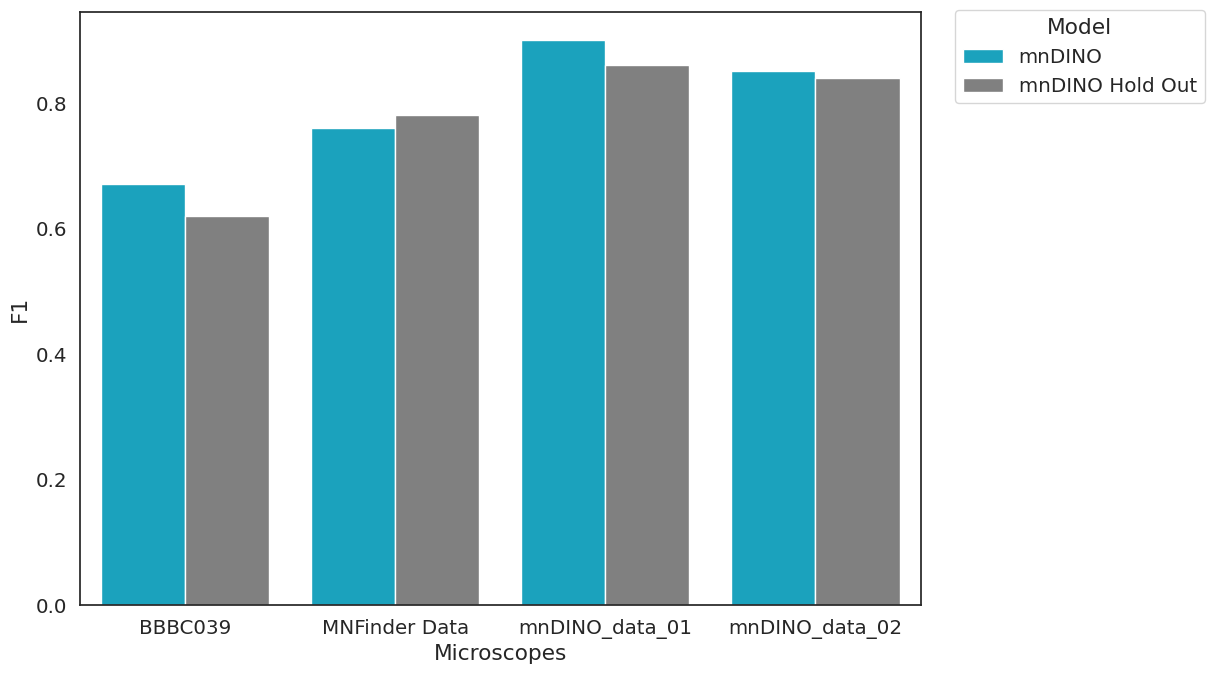

In [13]:
labels = ['BBBC039', 'MNFinder Data', 'mnDINO_data_01', 'mnDINO_data_02']
plt.figure(figsize=(13,7))
ax = sb.barplot(
    data=df,
    x='Subset',
    y='F1',
    hue='Model',
    hue_order = ['mnDINO', 'mnDINO Hold Out'],
    order=labels,
    palette=methods_color
)

sb.move_legend(ax,
               loc='upper right',
               bbox_to_anchor=(1.35,1.02))

plt.xlabel('Microscopes')
# plt.title('Leave Microscope Out')
plt.tight_layout()
# plt.legend(loc='upper left', fontsize='small')

# for container in ax.containers:
#     ax.bar_label(container, fmt='%.2f', label_type='edge', padding=0.8)
plt.show()

In [5]:
palette = dict(zip(df['Model'].unique(), sb.color_palette()))
palette

{'mnDINO Hold Out': (0.12156862745098039,
  0.4666666666666667,
  0.7058823529411765),
 'mnDINO': (1.0, 0.4980392156862745, 0.054901960784313725)}

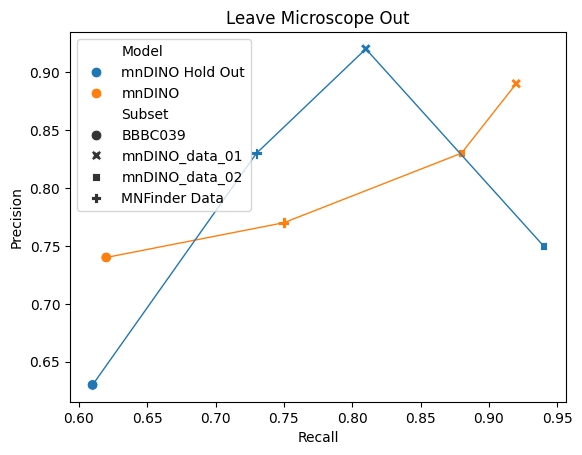

In [6]:
plot1 = sb.scatterplot(
    data=df,
    x='Recall',
    y='Precision',
    hue='Model',
    style='Subset',
    s=60,
)
palette = dict(zip(df['Model'].unique(), sb.color_palette()))
for model, group_data in df.groupby('Model'):
    group_data = group_data.sort_values('Recall')
    plt.plot(
        group_data['Recall'],
        group_data['Precision'],
        color=palette[model],
        marker=None,
        linestyle='-',
        linewidth=1
    )
    
plot1.set_title('Leave Microscope Out')
plt.show()

# Leave Cell-Line Out

In [11]:
df2 = pd.read_csv(f'{LOAD_PATH}figure5/figure5_LCO.csv')
df2.head()

,Precision,Recall,F1,Model,Cell-line
0,0.55,0.62,0.59,mnDINO Hold Out,U2OS
1,0.72,0.87,0.79,mnDINO Hold Out,HeLa
2,0.85,0.79,0.82,mnDINO Hold Out,RPE1
3,0.74,0.62,0.67,mnDINO,U2OS
4,0.82,0.91,0.86,mnDINO,HeLa


In [14]:
labels = ['U2OS', 'HeLa', 'RPE1']
diffs = []
for l in labels:
    hold_out_f1 = df2.loc[(df2['Cell-line'] == l) & (df2.Model == 'mnDINO Hold Out'), 'F1'].item()
    f1 = df2.loc[(df2['Cell-line'] == l) & (df2.Model == 'mnDINO'), 'F1'].item()
    diff = f1 - hold_out_f1
    diffs.append(diff)
    
print(diffs)
avg = np.sum(diffs) / len(diffs) * 100
print(f'Average drop percentage is: {avg:.2f}%')

[0.08000000000000007, 0.06999999999999995, 0.020000000000000018]
Average drop percentage is: 5.67%


- Cell-Line Out

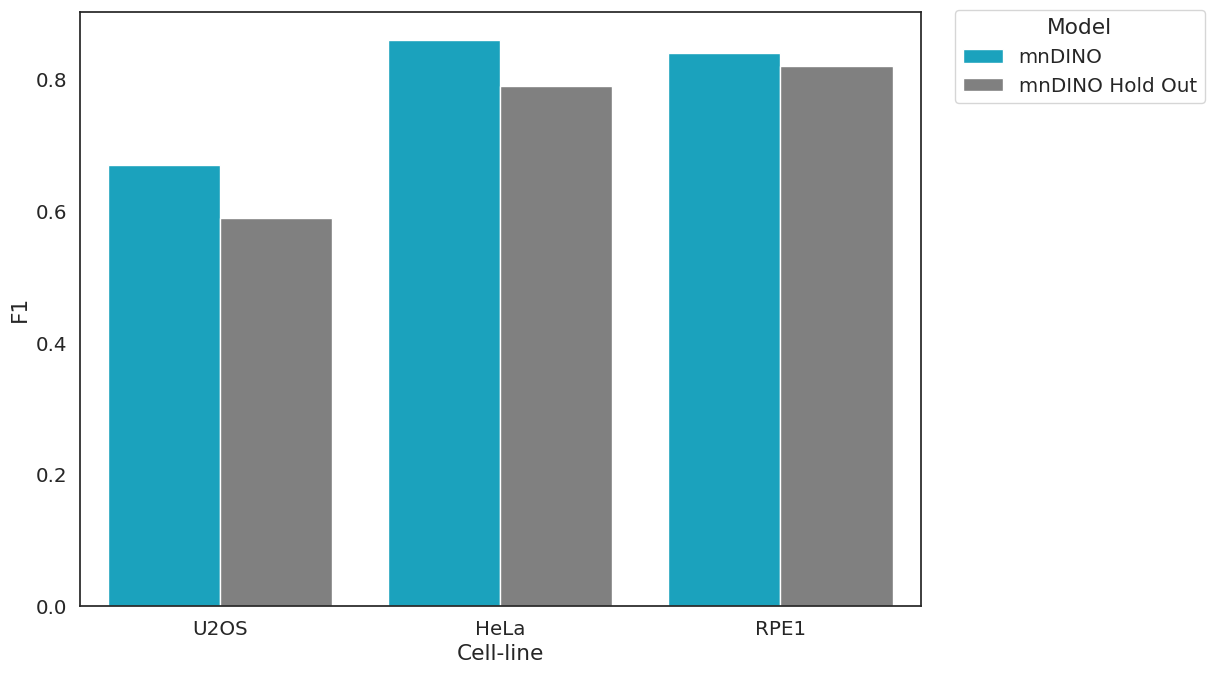

In [14]:
plt.figure(figsize=(13, 7))

ax = sb.barplot(
    data=df2,
    x='Cell-line',
    y='F1',
    hue='Model',
    hue_order = ['mnDINO', 'mnDINO Hold Out'],
    palette=methods_color
)

sb.move_legend(ax,
               loc='upper right',
               bbox_to_anchor=(1.35,1.02))

# plt.title('Leave Cell-line Out')
plt.tight_layout()
# plt.legend(loc='upper left', fontsize='small')

# for container in ax.containers:
#     ax.bar_label(container, fmt='%.2f', label_type='edge', padding=1)
plt.show()

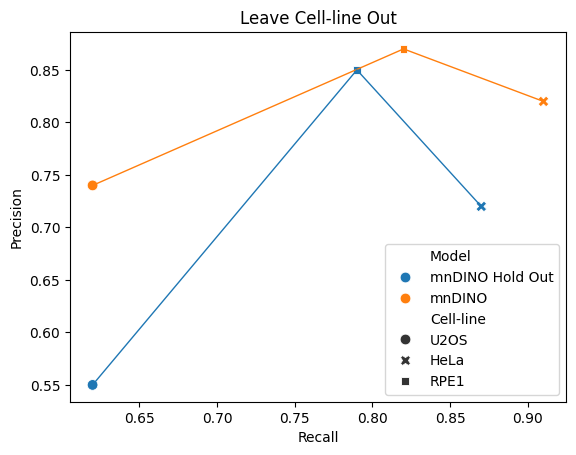

In [9]:
plot2 = sb.scatterplot(
    data=df2,
    x='Recall',
    y='Precision',
    hue='Model',
    style='Cell-line',
    s=60
)

palette = dict(zip(df2['Model'].unique(), sb.color_palette()))
for model, group_data in df2.groupby('Model'):
    group_data = group_data.sort_values('Recall')
    plt.plot(
        group_data['Recall'],
        group_data['Precision'],
        color=palette[model],
        marker=None,
        linestyle='-',
        linewidth=1
    )

plot2.set_title('Leave Cell-line Out')
plt.show()

# Inference Time

In [4]:
time = pd.read_csv(f'{LOAD_PATH}computational_cost/mndino_inference_time.csv')
# cost['Inference Time'] = cost['Inference Time'].apply(lambda x: int(x) if x > 1 else round(x, 1))
time.head()

,Subset,Method,Inference Time,F1,Step
0,BBBC039,mnDINO,8.674065,0.665779,16
1,mnDINO_data_01,mnDINO,527.143770,0.906966,16
2,mnDINO_data_02,mnDINO,441.661664,0.881833,16
3,MNFinder Data,mnDINO,17.468798,0.813847,16
4,BBBC039,mnDINO,2.829853,0.666509,32


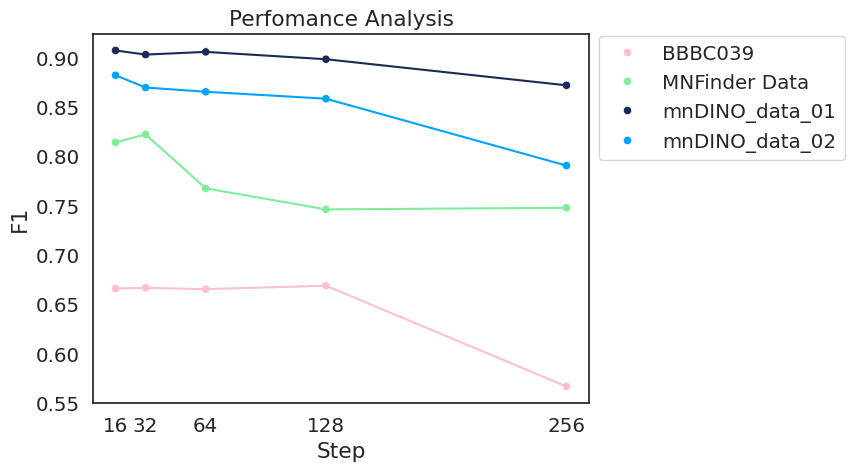

In [19]:
labels = ['BBBC039', 'MNFinder Data', 'mnDINO_data_01', 'mnDINO_data_02']

datasets_colors = {'BBBC039':'#FFC0CB',
                   'MNFinder Data':'#80ED99',
                   'mnDINO_data_01':'#192A56',
                   'mnDINO_data_02':'#00A3FF'}

ax = sb.scatterplot(
    x=time['Step'],
    y=time['F1'],
    hue=time['Subset'],
    hue_order=labels,
    sizes=(20, 150),
    palette=datasets_colors
)

# palette = dict(zip(labels, sb.color_palette()))
for subset, group_data in time.groupby('Subset'):
    group_data = group_data.sort_values('Step')
    plt.plot(
        group_data['Step'],
        group_data['F1'],
        color=datasets_colors[subset],
        linestyle='-'
    )

    
plt.xticks(time.Step.unique())
plt.title('Perfomance Analysis')

handles, labels = ax.get_legend_handles_labels()


ax.legend(handles, labels, bbox_to_anchor=(1, 1.02), loc='upper left')
plt.show()

## Inference time of each window in MNDINO

In [5]:
PATH = '/hdd/jcaicedo/projects/micronuclei_detection/Train_and_Eval/mndino_data/data_to_publish/annotated_mn_datasets/train/images'

DF_PATH = '/hdd/jcaicedo/projects/micronuclei_detection/Train_and_Eval/mndino_data/data_to_publish/annotated_mn_datasets/'
df = pd.read_csv(os.path.join(DF_PATH, 'metadata.csv'))

bbbc039_im = skimage.io.imread(os.path.join(PATH, df[(df.split == 'train') & (df.datasets == 'BBBC039')].reset_index().iloc[0].filenames))
mnDINO01_img = skimage.io.imread(os.path.join(PATH, df[(df.split == 'train') & (df.datasets == 'mnDINO_data_01')].reset_index().iloc[0].filenames))
mnDINO02_img = skimage.io.imread(os.path.join(PATH, df[(df.split == 'train') & (df.datasets == 'mnDINO_data_02')].reset_index().iloc[0].filenames))
mnfinder_img = skimage.io.imread(os.path.join(PATH, df[(df.split == 'train') & (df.datasets == 'mnfinder_train')].reset_index().iloc[0].filenames))

image_sources = {
    'BBBC039': bbbc039_im,
    'mnDINO_data_01': mnDINO01_img, 
    'mnDINO_data_02': mnDINO02_img,
    'MNFinder Data': mnfinder_img
}

for subset, img in image_sources.items():
    time.loc[(time['Subset'] == subset), ['H', 'W']] = img.shape[:2]

In [6]:
WINDOW_SIZE = 256
time["number of patches"] = ((time['H'] - WINDOW_SIZE) / time['Step']) * ((time['W'] - WINDOW_SIZE) / time['Step'])

# align the time on a 1024 x 1024 Image
time['Inference Time per Image'] = time['Inference Time'] / time["number of patches"] * ((1024 / time['Step']) ** 2)
time

,Subset,Method,Inference Time,F1,Step,H,W,number of patches,Inference Time per Image
0,BBBC039,mnDINO,8.674065,0.665779,16,520.0,696.0,453.750000,78.300765
1,mnDINO_data_01,mnDINO,527.143770,0.906966,16,2960.0,2960.0,28561.000000,75.598924
2,mnDINO_data_02,mnDINO,441.661664,0.881833,16,2720.0,2720.0,23716.000000,76.279566
3,MNFinder Data,mnDINO,17.468798,0.813847,16,768.0,869.0,1226.000000,58.362314
4,BBBC039,mnDINO,2.829853,0.666509,32,520.0,696.0,113.437500,25.545074
5,mnDINO_data_01,mnDINO,158.322341,0.902767,32,2960.0,2960.0,7140.250000,22.705378
6,mnDINO_data_02,mnDINO,132.412973,0.869396,32,2720.0,2720.0,5929.000000,22.869098
7,MNFinder Data,mnDINO,5.676847,0.821923,32,768.0,869.0,306.500000,18.966040
8,BBBC039,mnDINO,0.850689,0.665148,64,520.0,696.0,28.359375,7.679168
9,mnDINO_data_01,mnDINO,40.328683,0.905515,64,2960.0,2960.0,1785.062500,5.783631


In [7]:
time[time.Subset == 'mnDINO_data_01']

,Subset,Method,Inference Time,F1,Step,H,W,number of patches,Inference Time per Image
1,mnDINO_data_01,mnDINO,527.143770,0.906966,16,2960.0,2960.0,28561.000000,75.598924
5,mnDINO_data_01,mnDINO,158.322341,0.902767,32,2960.0,2960.0,7140.250000,22.705378
9,mnDINO_data_01,mnDINO,40.328683,0.905515,64,2960.0,2960.0,1785.062500,5.783631
13,mnDINO_data_01,mnDINO,10.614942,0.898066,128,2960.0,2960.0,446.265625,1.522314
17,mnDINO_data_01,mnDINO,2.807490,0.871652,256,2960.0,2960.0,111.566406,0.402629


In [8]:
time[time.Subset == 'mnDINO_data_02']

,Subset,Method,Inference Time,F1,Step,H,W,number of patches,Inference Time per Image
2,mnDINO_data_02,mnDINO,441.661664,0.881833,16,2720.0,2720.0,23716.000000,76.279566
6,mnDINO_data_02,mnDINO,132.412973,0.869396,32,2720.0,2720.0,5929.000000,22.869098
10,mnDINO_data_02,mnDINO,32.986844,0.865110,64,2720.0,2720.0,1482.250000,5.697171
14,mnDINO_data_02,mnDINO,8.773303,0.858084,128,2720.0,2720.0,370.562500,1.515241
18,mnDINO_data_02,mnDINO,2.322342,0.790319,256,2720.0,2720.0,92.640625,0.401093


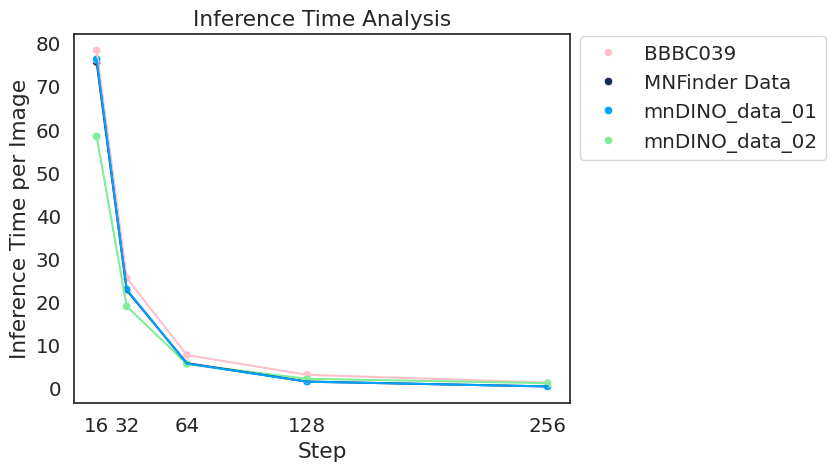

In [11]:
order = ['BBBC039', 'MNFinder Data', 'mnDINO_data_01', 'mnDINO_data_02']

fig, ax = plt.subplots()

ax = sb.scatterplot(
    data=time,
    x='Step',
    y='Inference Time per Image',
    hue='Subset',
    sizes=(20, 150),
    palette=datasets_colors
)

# palette = dict(zip(order, sb.color_palette()))
for subset, group_data in time.groupby('Subset'):
    group_data = group_data.sort_values('Step')
    plt.plot(
        group_data['Step'],
        group_data['Inference Time per Image'],
        color=datasets_colors[subset],
        linestyle='-'
    )

# ax.set_yscale('log')

plt.xticks(time.Step.unique())
# plt.yticks([0, 0.05, 0.1])
plt.ylabel('Inference Time per Image')
plt.title('Inference Time Analysis')

handles, _ = ax.get_legend_handles_labels()


ax.legend(handles, order, bbox_to_anchor=(1, 1.02), loc='upper left')
plt.show()
plt.show()

# Computational Cost across subset

In [15]:
LOAD_PATH = '/hdd/jcaicedo/projects/micronuclei_detection/Train_and_Eval/mndino_data/figures/mndino_figures/'
cost = pd.read_csv(f'{LOAD_PATH}computational_cost/computational_cost.csv')
# df = pd.read_csv('/scr/yren/annotated_mn_datasets/metadata.csv')
cost.Subset.unique()

array(['BBBC039', 'mnDINO_data_01', 'mnDINO_data_02', 'MNFinder Data'],
      dtype=object)

In [16]:
cost

,Subset,Method,Inference Time
0,BBBC039,mnDINO,0.853484
1,mnDINO_data_01,mnDINO,40.286448
2,mnDINO_data_02,mnDINO,32.974286
3,MNFinder Data,mnDINO,1.741493
4,BBBC039,MNFinder,2.876928
5,mnDINO_data_01,MNFinder,403.925678
6,mnDINO_data_02,MNFinder,226.452734
7,MNFinder Data,MNFinder,8.136476
8,BBBC039,Cellpose,2.119855
9,mnDINO_data_01,Cellpose,71.071386


- Total Inference Time across all methods

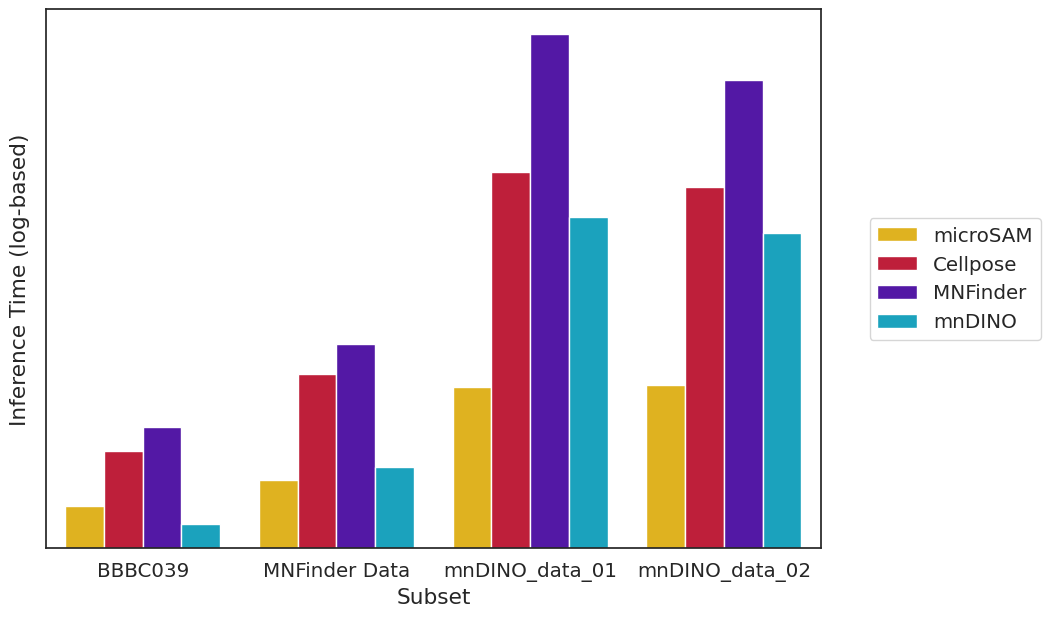

In [18]:
methods_color = {'mnDINO':'#00B4D8',
                 'MNFinder':'#4F00BC',
                 'Cellpose':'#D90429',
                 'microSAM':'#FFC300'}

labels = ['BBBC039', 'MNFinder Data', 'mnDINO_data_01', 'mnDINO_data_02']

fig, ax1 = plt.subplots(figsize=(10,7))

# Left y-axis with log scale
sb.barplot(
    data=cost,
    x='Subset',
    y='Inference Time',
    hue='Method',
    ax=ax1,
    palette=methods_color,
    order = labels,
    hue_order=['microSAM', 'Cellpose', 'MNFinder', 'mnDINO']
)

ax1.set_yscale('log')
ax1.set_ylabel('Inference Time (log-based)')
# ax1.set_title('Computational Cost')
ax1.set_yticks([])
ax1.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))


plt.show()